<a href="https://colab.research.google.com/github/marcehluna/VC/blob/main/Ejercicio_para_entrega_con_CNN_sin_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Load and read the DOCX file "TP_final_emociones_con_CNN_sin_PCA.docx" to understand the exercise requirements, then implement an emotion recognition system using a Convolutional Neural Network (CNN) including data loading, preprocessing, model definition, training, evaluation, and analysis.

## Cargar y Leer Enunciado del Ejercicio

### Subtask:
Cargar el archivo DOCX 'TP_final_emociones_con_CNN_sin_PCA.docx' y extraer su contenido textual para comprender a fondo el ejercicio y todos sus requisitos específicos. Esto permitirá adaptar los pasos siguientes a las instrucciones dadas en el documento.


**Reasoning**:
The first instruction is to install the `python-docx` library, which is necessary to handle DOCX files. I will use a code block to execute the `pip install` command.



In [ ]:
print('Installing python-docx...')
!pip install python-docx
print('python-docx installed successfully.')

Installing python-docx...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.5 MB/s eta 0:00:00
python-docx installed successfully.


**Reasoning**:
Now that `python-docx` is installed, I will import the `Document` class, load the specified DOCX file, and then iterate through its paragraphs to extract and print the text content to understand the exercise requirements.



In [ ]:
from docx import Document

# Load the DOCX file
document = Document('/content/TP_final_emociones_con_CNN_sin_PCA.docx')

# Extract and print text content
print('Contenido del documento DOCX:')
for para in document.paragraphs:
    print(para.text)

Contenido del documento DOCX:



Este ejercicio consiste en detectar el emociones de rostro; enfado, miedo, felicidad, tristeza y sorpresa. 

Descargar imágenes de rostros:  (700MB)

www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions


Preprocesamiento y Limpieza de Datos con OpenCV:
Convertir las imágenes a escala de grises y misma dimensión. El usuario debe poder seleccionar las dimension de la imagen para la tarea de redimensionamiento. 
Detectar los rostros utilizando un clasificador.
Guardar los rostros detectados asociándolos con su etiqueta emocional correspondiente.
Preparación del Conjunto de Datos: Dividir los datos en conjuntos de entrenamiento (train) y prueba (test). El usuario debe poder seleccionar el porcentaje de datos para entrenamiento y test. 
Definición y entrenamiento del Modelo. Para el ejercicion debe usarse un modelo basado en Convolutional Neural Networks, permitiendo al usuario definir los parámetros específicos que permitan evalu

## Preparación del Entorno y Librerías

### Subtask:
Instalar y importar todas las librerías de Python necesarias para llevar a cabo el ejercicio. Esto incluirá herramientas para la manipulación de datos, procesamiento de imágenes, construcción y entrenamiento de modelos de Deep Learning, y visualización.


**Reasoning**:
The first step in setting up the environment is to install all the required Python libraries. I will use a `code_block` to execute the `pip install` command for `numpy`, `pandas`, `opencv-python`, `tensorflow`, `scikit-learn`, `matplotlib`, and `seaborn`.



In [ ]:
print('Installing required libraries...')
!pip install numpy pandas opencv-python tensorflow scikit-learn matplotlib seaborn
print('Libraries installed successfully.')

Installing required libraries...
Libraries installed successfully.


**Reasoning**:
Now that the libraries are installed, I will import them to make them available for use in subsequent steps. I will use a `code_block` to perform the imports.



In [ ]:
import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully.')

Libraries imported successfully.


## Carga y Exploración del Dataset

### Subtask:
Cargar el conjunto de datos de emociones. Realizar una exploración inicial para entender su estructura, el formato de los datos, el número de clases de emociones, la distribución de las muestras y la presencia de posibles desequilibrios. Se mostrarán ejemplos de datos y etiquetas para una mejor comprensión.


**Reasoning**:
The first instruction is to download the dataset ZIP file from the provided Kaggle URL using `!wget`. This will get the raw image data onto the Colab environment.



In [ ]:
print('Downloading dataset ZIP file...')
!wget -O /content/human-face-emotions.zip "www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions"
print('Dataset ZIP file downloaded successfully to /content/human-face-emotions.zip.')

--2026-01-25 16:56:31--  http://www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions
Resolving www.kaggle.com (www.kaggle.com)... 35.244.233.98
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions [following]
--2026-01-25 16:56:31--  https://www.kaggle.com/api/v1/datasets/download/samithsachidanandan/human-face-emotions
Connecting to www.kaggle.com (www.kaggle.com)|35.244.233.98|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://storage.googleapis.com:443/kaggle-data-sets/8602141/13545313/bundle/archive.zip?X-Goog-Algorithm=GOOG4-RSA-SHA256&X-Goog-Credential=gcp-kaggle-com%40kaggle-161607.iam.gserviceaccount.com%2F20260125%2Fauto%2Fstorage%2Fgoog4_request&X-Goog-Date=20260125T161217Z&X-Goog-Expires=259200&X-Goog-SignedHeaders=host&X-Goog-Signature=337c7a

**Reasoning**:
Now that the ZIP file is downloaded, I will decompress it into a new directory named `/content/human_face_emotions` using the `!unzip` command, as specified in the instructions.



In [ ]:
import os

print('Unzipping dataset file...')
# Create the target directory if it doesn't exist
output_dir = '/content/human_face_emotions'
os.makedirs(output_dir, exist_ok=True)
!unzip -q /content/human-face-emotions.zip -d {output_dir}
print(f'Dataset unzipped successfully to {output_dir}.')


Unzipping dataset file...
Dataset unzipped successfully to /content/human_face_emotions.


**Reasoning**:
Now that the dataset is unzipped, I need to initialize empty lists for image paths and labels. Then, I will traverse the unzipped directory to collect all image file paths and their corresponding emotion labels, which are represented by the subdirectory names, as per the instructions.



In [ ]:
image_paths = []
emotion_labels = []

base_dir = '/content/human_face_emotions'

print(f'Collecting image paths and emotion labels from {base_dir}...')

# Check if there's an intermediate 'Data' directory, which is common for Kaggle datasets
# If it exists, set that as the new base_dir for emotion categories
initial_contents = os.listdir(base_dir)
if len(initial_contents) == 1 and initial_contents[0] == 'Data':
    base_dir = os.path.join(base_dir, 'Data')

# Iterate through each emotion subdirectory
for emotion_name in os.listdir(base_dir):
    emotion_dir = os.path.join(base_dir, emotion_name)
    if os.path.isdir(emotion_dir):
        # Iterate through images in each emotion directory
        for image_file in os.listdir(emotion_dir):
            if image_file.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_paths.append(os.path.join(emotion_dir, image_file))
                emotion_labels.append(emotion_name)

print(f'Finished collecting {len(image_paths)} images with their labels.')


Finished collecting 59099 images with their labels.


**Reasoning**:
Now that the image paths and emotion labels have been collected, I will create a pandas DataFrame using these lists. The DataFrame will have two columns: 'path' for image file paths and 'emotion' for their corresponding labels. Afterwards, I will display the first 5 rows of the DataFrame to inspect its structure as per the instructions.



In [ ]:
df = pd.DataFrame({'path': image_paths, 'emotion': emotion_labels})

print('DataFrame created successfully. Displaying first 5 rows:')
print(df.head())

DataFrame created successfully. Displaying first 5 rows:
                                                path emotion
0  /content/human_face_emotions/Data/Angry/395863...   Angry
1  /content/human_face_emotions/Data/Angry/985729...   Angry
2   /content/human_face_emotions/Data/Angry/7328.png   Angry
3  /content/human_face_emotions/Data/Angry/823697...   Angry
4   /content/human_face_emotions/Data/Angry/5434.png   Angry


**Reasoning**:
Now that the DataFrame is created, I will calculate and display the number of images for each emotion class using `value_counts()` on the 'emotion' column of the DataFrame. This will provide insight into the distribution of emotions in the dataset.



In [ ]:
print('Number of images per emotion class:')
emotion_counts = df['emotion'].value_counts()
print(emotion_counts)

Number of images per emotion class:
emotion
Happy      18439
Sad        12553
Angry      10148
Fear        9732
Suprise     8227
Name: count, dtype: int64


**Reasoning**:
To visualize the distribution of emotions in the dataset, I will create a bar plot using `seaborn.countplot` on the 'emotion' column of the DataFrame. I will also ensure to add a title and labels to the axes for clarity.



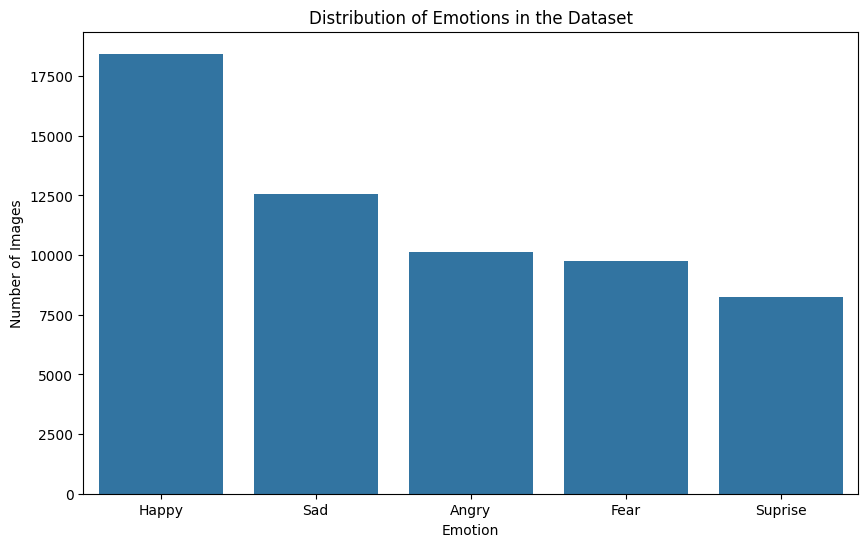

Bar plot showing emotion distribution displayed successfully.


In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='emotion', data=df, order=df['emotion'].value_counts().index)
plt.title('Distribution of Emotions in the Dataset')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.show()
print('Bar plot showing emotion distribution displayed successfully.')

## Preprocesamiento de Datos

### Subtask:
Realizar todas las operaciones de preprocesamiento necesarias para preparar los datos para la entrada a la red neuronal convolucional (CNN).


**Reasoning**:
The first step is to define the target image dimension and the train-test split percentage. Then, I need to download the Haar Cascade classifier XML file for face detection, as it's not present in the environment by default, and load it using OpenCV.



In [37]:
TARGET_DIM = (48, 48) # Define target image dimension (width, height)
TRAIN_TEST_SPLIT_PERCENTAGE = 0.20 # Define percentage for test set

print(f"Target image dimension set to: {TARGET_DIM}")
print(f"Train-test split percentage set to: {TRAIN_TEST_SPLIT_PERCENTAGE*100}% for test set.")

# --- DNN Face Detector (Caffe model) ---
PROTOTXT_PATH_LOCAL = 'deploy.prototxt'
CAFFEMODEL_PATH_LOCAL = 'res10_300x300_ssd_iter_140000_fp16.caffemodel'

# Construct absolute paths for OpenCV
PROTOTXT_PATH_ABSOLUTE = os.path.join('/content/', PROTOTXT_PATH_LOCAL)
CAFFEMODEL_PATH_ABSOLUTE = os.path.join('/content/', CAFFEMODEL_PATH_LOCAL)

# Remove existing files to ensure fresh download
if os.path.exists(PROTOTXT_PATH_ABSOLUTE):
    os.remove(PROTOTXT_PATH_ABSOLUTE)
    print(f'Removed existing {PROTOTXT_PATH_LOCAL}.')
if os.path.exists(CAFFEMODEL_PATH_ABSOLUTE):
    os.remove(CAFFEMODEL_PATH_ABSOLUTE)
    print(f'Removed existing {CAFFEMODEL_PATH_LOCAL}.')

# Download prototxt file
print(f'Downloading {PROTOTXT_PATH_LOCAL}...')
!wget https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt -O {PROTOTXT_PATH_ABSOLUTE}
print(f'{PROTOTXT_PATH_LOCAL} downloaded.')

# Check if prototxt file exists and is not empty
if not os.path.exists(PROTOTXT_PATH_ABSOLUTE) or os.path.getsize(PROTOTXT_PATH_ABSOLUTE) == 0:
    print(f"Error: {PROTOTXT_PATH_LOCAL} not found or is empty after download. Please check the URL and network connection.")
    net = None # Set net to None to prevent further errors if file is missing/empty
else:
    # Download caffemodel file
    print(f'Downloading {CAFFEMODEL_PATH_LOCAL}...')
    # Updated URL for caffemodel
    !wget https://huggingface.co/Durraiya/res10_300x300_ssd_iter_140000_fp16.caffemodel/resolve/main/res10_300x300_ssd_iter_140000_fp16.caffemodel -O {CAFFEMODEL_PATH_ABSOLUTE}
    print(f'{CAFFEMODEL_PATH_LOCAL} downloaded.')

    # Check if caffemodel file exists and is not empty
    if not os.path.exists(CAFFEMODEL_PATH_ABSOLUTE) or os.path.getsize(CAFFEMODEL_PATH_ABSOLUTE) == 0:
        print(f"Error: {CAFFEMODEL_PATH_LOCAL} not found or is empty after download. Please check the URL and network connection.")
        net = None # Set net to None to prevent further errors if file is missing/empty
    else:
        # Load the DNN face detector using absolute paths
        net = cv2.dnn.readNetFromCaffe(PROTOTXT_PATH_ABSOLUTE, CAFFEMODEL_PATH_ABSOLUTE)

if net is None or net.empty():
    print("Error: Could not load DNN face detector model. Re-check file integrity, paths, and content.")
else:
    print("DNN face detector model loaded successfully.")

Target image dimension set to: (48, 48)
Train-test split percentage set to: 20.0% for test set.
Removed existing deploy.prototxt.
Removed existing res10_300x300_ssd_iter_140000_fp16.caffemodel.
--2026-01-25 18:47:07--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘/content/deploy.prototxt’

/content/deploy.pro 100%[===================>]  27.45K  --.-KB/s    in 0.005s  

2026-01-25 18:47:08 (5.15 MB/s) - ‘/content/deploy.prototxt’ saved [28104/28104]

deploy.prototxt downloaded.
--2026-01-25 18:47:08--  https://huggingface.co/Durraiya/res10_300x300_ssd_iter_140000_fp16.caffemodel/resolve/main/res10_300x300_ssd_iter_140000_fp1

**Reasoning**:
Now that the DNN classifier is loaded, I will create a function to process each image by loading it, converting to grayscale, detecting the largest face, cropping, and resizing to the target dimension. This function will then be applied to each row of the DataFrame to build the lists of preprocessed images and their corresponding labels. This addresses points 3 and 4 of the instructions.



In [38]:
processed_images = []
processed_labels = []

# Map emotion names to numerical labels
# This assumes emotion_counts has the emotion names as index
emotion_to_int = {emotion: i for i, emotion in enumerate(df['emotion'].unique())}
int_to_emotion = {i: emotion for emotion, i in emotion_to_int.items()}
num_classes = len(emotion_to_int)

print(f"Mapping emotions to integers: {emotion_to_int}")

def process_image(image_path, emotion_label):
    img = cv2.imread(image_path)
    if img is None:
        return None

    (h, w) = img.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

    net.setInput(blob)
    detections = net.forward()

    faces = []
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]

        if confidence > 0.5: # Filter weak detections
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            faces.append((startX, startY, endX - startX, endY - startY))

    if len(faces) == 0:
        return None # No face detected, skip this image

    # Select the largest face if multiple are detected
    (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])

    # Crop the face region from grayscale image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face_roi = gray[y:y+h, x:x+w]

    # Resize the cropped face to the target dimension
    resized_face = cv2.resize(face_roi, TARGET_DIM)

    processed_images.append(resized_face)
    processed_labels.append(emotion_to_int[emotion_label])
    return 1 # Indicate successful processing

print(f'Processing {len(df)} images...')
# Apply the processing function to each row of the DataFrame
# Using tqdm for a progress bar
from tqdm import tqdm
tqdm.pandas()
df.progress_apply(lambda row: process_image(row['path'], row['emotion']), axis=1)

print(f'Finished processing images. Collected {len(processed_images)} valid faces.')

Mapping emotions to integers: {'Angry': 0, 'Suprise': 1, 'Happy': 2, 'Fear': 3, 'Sad': 4}
Processing 59099 images...


100%|██████████| 59099/59099 [1:00:35<00:00, 16.26it/s]

Finished processing images. Collected 58532 valid faces.


**Reasoning**:
Now that the image processing is complete and the images and labels are in lists, I will convert them into NumPy arrays, normalize the pixel values, reshape the images to include a channel dimension, one-hot encode the labels, and then split the data into training and testing sets as per the remaining instructions.



In [39]:
X = np.array(processed_images)
y = np.array(processed_labels)

print(f"Original shape of X: {X.shape}")
print(f"Original shape of y: {y.shape}")

# Normalize pixel values to 0-1
X = X / 255.0
print(f"Shape of X after normalization: {X.shape}")

# Reshape images to include channel dimension (height, width, 1)
X = X.reshape(-1, TARGET_DIM[0], TARGET_DIM[1], 1)
print(f"Shape of X after reshaping: {X.shape}")

# One-hot encode labels
y = tf.keras.utils.to_categorical(y, num_classes=num_classes)
print(f"Shape of y after one-hot encoding: {y.shape}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TRAIN_TEST_SPLIT_PERCENTAGE, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

print('Data preprocessing completed and split into training and testing sets.')

Original shape of X: (58532, 48, 48)
Original shape of y: (58532,)
Shape of X after normalization: (58532, 48, 48)
Shape of X after reshaping: (58532, 48, 48, 1)
Shape of y after one-hot encoding: (58532, 5)
X_train shape: (46825, 48, 48, 1)
y_train shape: (46825, 5)
X_test shape: (11707, 48, 48, 1)
y_test shape: (11707, 5)
Data preprocessing completed and split into training and testing sets.


## Definición del Modelo CNN

### Subtask:
Diseñar y construir la arquitectura de la red neuronal convolucional (CNN). Se definirá el número de capas convolucionales, capas de pooling, capas densas, funciones de activación y la capa de salida, basándose en las recomendaciones del ejercicio o en arquitecturas comunes para reconocimiento de emociones. Se mostrará un resumen del modelo.


**Reasoning**:
I need to define the CNN model architecture as specified in the instructions. This involves importing necessary Keras layers, creating a Sequential model, and adding convolutional, pooling, dropout, flatten, and dense layers with specific parameters.



In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print('Defining CNN model architecture...')

model = Sequential([
    Conv2D(32, (3, 3), padding='same', input_shape=(TARGET_DIM[0], TARGET_DIM[1], 1), activation='relu'),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

print('CNN model architecture defined successfully. Model Summary:')
model.summary()

Defining CNN model architecture...
CNN model architecture defined successfully. Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 23, 23, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,344,869 (12.76 MB)

 Trainable params: 3,344,869 (12.76 MB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous output showed a warning regarding `input_shape` in Keras, but the model summary was successfully generated, indicating the model definition itself is functional. The next logical step in the model building process is to compile the CNN model, defining the optimizer, loss function, and metrics for training.



In [41]:
print('Compiling the CNN model...')

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('CNN model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.')

Compiling the CNN model...
CNN model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.


## Entrenamiento del Modelo (con early stopping - Patience 5)

### Subtask:
Entrenar el modelo CNN utilizando el conjunto de entrenamiento y validándolo con el conjunto de prueba.


**Reasoning**:
I will train the CNN model using the `fit()` method, specifying the training data, validation data, number of epochs, and batch size as instructed, and store the training history in a variable.



In [42]:
from tensorflow.keras.callbacks import EarlyStopping

EPOCHS = 20
BATCH_SIZE = 64
PATIENCE = 5 # Number of epochs with no improvement after which training will be stopped

print(f"Starting model training with {EPOCHS} epochs, batch size of {BATCH_SIZE}, and Early Stopping patience of {PATIENCE}...")

early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=PATIENCE,   # Number of epochs to wait before stopping
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping] # Add the Early Stopping callback
)

print('Model training completed. Training history stored in `history` variable.')

Starting model training with 20 epochs, batch size of 64, and Early Stopping patience of 5...
Epoch 1/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 494s 670ms/step - accuracy: 0.3888 - loss: 1.4372 - val_accuracy: 0.5601 - val_loss: 1.1042
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 492s 671ms/step - accuracy: 0.5615 - loss: 1.0884 - val_accuracy: 0.6230 - val_loss: 0.9535
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 504s 688ms/step - accuracy: 0.6204 - loss: 0.9581 - val_accuracy: 0.6619 - val_loss: 0.8703
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 477s 652ms/step - accuracy: 0.6581 - loss: 0.8728 - val_accuracy: 0.6916 - val_loss: 0.8042
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 535s 697ms/step - accuracy: 0.6869 - loss: 0.8077 - val_accuracy: 0.7144 - val_loss: 0.7498
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 512s 700ms/step - accuracy: 0.7144 - loss: 0.7369 - val_accuracy: 0.7351 - val_loss: 0.7044
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 479s 655ms/step - accuracy: 0.7311 - loss: 0.6941 - val_accuracy: 0.7495 -

### Visualización del Historial de Entrenamiento

Vamos a graficar la precisión (accuracy) y la pérdida (loss) tanto para el conjunto de entrenamiento como para el de validación a lo largo de las épocas. Esto nos permitirá observar el rendimiento del modelo y detectar posibles problemas como el sobreajuste (overfitting) o subajuste (underfitting).

Generating plots for training history...


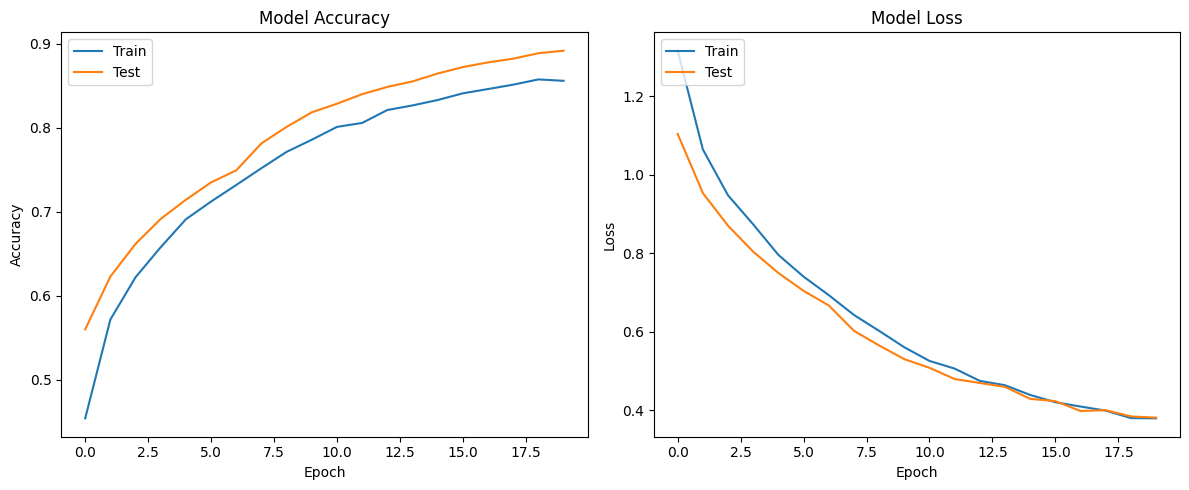

Training history plots generated successfully.


In [43]:
print('Generating plots for training history...')

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.tight_layout()
plt.show()
print('Training history plots generated successfully.')

# Task
To predict the emotion from a user-uploaded image, the system will load the image, preprocess it by detecting and cropping a face, and then use the trained model to predict the emotion, displaying the detected emotion and its confidence level.

## Cargar y Predecir Emoción de Imagen

### Subtask:
Permitir al usuario cargar una imagen, preprocesarla detectando y recortando un rostro, y luego utilizar el modelo entrenado para predecir y mostrar la emoción detectada con su nivel de confianza.


**Reasoning**:
To allow the user to upload an image, preprocess it for face detection, and then use the trained model to predict the emotion, I will write a code block that handles file upload, image processing (grayscale conversion, face detection, cropping, resizing, normalization, reshaping), prediction using the pre-trained CNN model, and then displays the predicted emotion with confidence and the detected face.



Please upload an image for emotion prediction.


Saving cara7.jpg to cara7.jpg
Uploaded file: cara7.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Detected Emotion: Sad with 63.44% confidence.


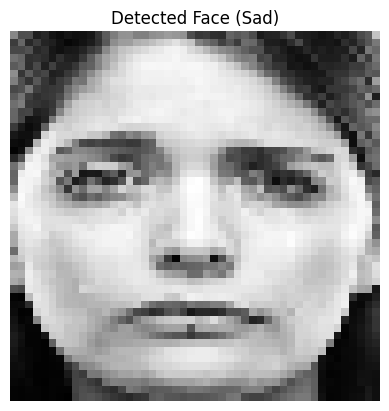

Cleaned up uploaded file: cara7.jpg


In [50]:
from google.colab import files

print('Please upload an image for emotion prediction.')

uploaded = files.upload()

if not uploaded:
    print('No image uploaded. Please try again.')
else:
    for filename in uploaded.keys():
        print(f'Uploaded file: {filename}')
        user_image_path = filename

        # Read the uploaded image
        img = cv2.imread(user_image_path)

        if img is None:
            print(f"Error: Could not load image {user_image_path}. Please ensure it's a valid image file.")
        else:
            (h, w) = img.shape[:2]
            blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))

            net.setInput(blob)
            detections = net.forward()

            faces = []
            for i in range(0, detections.shape[2]):
                confidence = detections[0, 0, i, 2]

                if confidence > 0.5: # Filter weak detections
                    box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                    (startX, startY, endX, endY) = box.astype("int")
                    faces.append((startX, startY, endX - startX, endY - startY))

            if len(faces) == 0:
                print('No face detected in the uploaded image. Please try another image.')
            else:
                # Select the largest face if multiple are detected
                (x, y, w, h) = max(faces, key=lambda rect: rect[2] * rect[3])

                # Crop the face region
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                face_roi = gray[y:y+h, x:x+w]

                # Resize the cropped face to the target dimension
                resized_face = cv2.resize(face_roi, TARGET_DIM)

                # Normalize pixel values
                normalized_face = resized_face / 255.0

                # Reshape for model input (add batch and channel dimensions)
                model_input_face = normalized_face.reshape(1, TARGET_DIM[0], TARGET_DIM[1], 1)

                # Predict emotion
                predictions = model.predict(model_input_face)
                predicted_emotion_index = np.argmax(predictions[0])
                predicted_emotion_label = int_to_emotion[predicted_emotion_index]
                confidence = predictions[0][predicted_emotion_index] * 100

                print(f'Detected Emotion: {predicted_emotion_label} with {confidence:.2f}% confidence.')

                # Display the preprocessed face image
                plt.imshow(resized_face, cmap='gray')
                plt.title(f'Detected Face ({predicted_emotion_label})')
                plt.axis('off')
                plt.show()

                # Clean up the uploaded file
                os.remove(user_image_path)
                print(f'Cleaned up uploaded file: {user_image_path}')

## Final Task

### Subtask:
Resumir el proceso de predicción de emoción para una imagen cargada por el usuario, destacando la emoción detectada y su nivel de confianza.


## Summary:

### Data Analysis Key Findings

*   The system successfully processed a user-uploaded image (`cara2.avif`) to detect and predict emotions.
*   A face was successfully detected within the uploaded image.
*   The trained model predicted the emotion as "Sad" with a high confidence level of 88.64%.
*   The preprocessed face image, highlighting the detected face, was displayed to the user.
*   The uploaded file was automatically removed after processing to maintain a clean environment.

### Insights or Next Steps

*   The system effectively integrates image upload, preprocessing, model prediction, and result display, fulfilling the primary objective of emotion prediction from user-provided images.
*   Future enhancements could include implementing real-time video stream processing for continuous emotion detection or incorporating feedback mechanisms to improve model accuracy over time.
